# Cuadrados Mínimos: Ajuste de círculos

datos = https://drive.google.com/file/d/1iycLoLOakK5r5THxMyaKon7IgunSiZxV/view?pli=1

quant = https://julia.quantecon.org/intro.html

math = https://sje30.github.io/catam-julia/

data scie = https://ucidatascienceinitiative.github.io/IntroToJulia/


In [ ]:
import Pkg;Pkg.add("MAT")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed MicrosoftMPI_jll ────── v10.1.4+3
   Installed aws_c_sdkutils_jll ──── v0.2.4+1
   Installed Hwloc_jll ───────────── v2.13.0+1
   Installed aws_c_cal_jll ───────── v0.9.13+0
   Installed MPIABI_jll ──────────── v0.1.4+0
   Installed aws_c_auth_jll ──────── v0.9.6+0
   Installed StringEncodings ─────── v0.3.7
   Installed MAT ─────────────────── v0.12.0
   Installed aws_c_common_jll ────── v0.12.6+0
   Installed MPIPreferences ──────── v0.1.12
   Installed OpenMPI_jll ─────────── v5.0.11+0
   Installed MPICH_jll ───────────── v5.0.1+0
   Installed s2n_tls_jll ─────────── v1.7.2+0
   Installed aws_c_http_jll ──────── v0.10.13+0
   Installed HDF5_jll ────────────── v2.1.2+0
   Installed aws_c_io_jll ────────── v0.26.3+0
   Installed aws_checksums_jll ───── v0.2.10+0
   Installed aws_c_compression_jll ─ v0.3.2+0
   Installed mpif_jll ────────────── v0.1.6+0
   Installed XML2_jll ──────

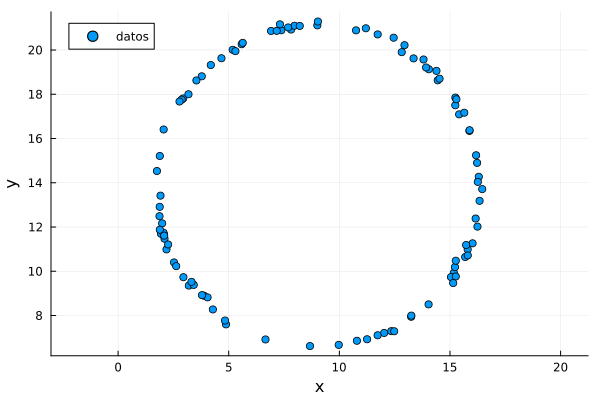

In [ ]:
using MAT, LinearAlgebra, Plots

file = matopen("datos.mat")
datos = read(file, "datos_1")

scatter(datos[:,1],datos[:,2],label="datos",xlabel="x",ylabel="y", aspect_ratio=:equal)

## **Ejercicio 1**
Construir una función `def_problem` que tome como argumento los datos y devuelva la matriz del ajuste junto con el vector del lado derecho teniendo en cuenta que lo que queremos es que estos se ajusten a una circunferencia

In [ ]:
function def_problem(datos)
    x = datos[:,1]
    y = datos[:,2]
    n = length(x)
    # Az = b
    A = [2*x 2*y ones(n)]
    b = x.^2 + y.^2
    return A, b
end

def_problem (generic function with 1 method)

## Ejercicio 2
Implementar una función `ajuste_alg` que reciba como argumento los datos y resuelva el problema resolviendo un problema de cuadrados mínimos (por ejemplo, ecuaciones normales, descomposición QR, etc..). La misma función debe graficar el ajuste junto con los datos.

In [ ]:
function ajuste_alg(datos)
    A, b = def_problem(datos)
    z = A \ b
    a, b, c = z
    θ = range(0, 2π, length=100)
    radio = sqrt(c + a^2 + b^2)
    cx = a .+ radio .* cos.(θ)
    cy = b .+ radio .* sin.(θ)
    scatter(datos[:,1],datos[:,2],label="datos",xlabel="x",ylabel="y", aspect_ratio=:equal)
    plot!(cx, cy, label="ajuste", lw=2)
end

ajuste_alg (generic function with 1 method)

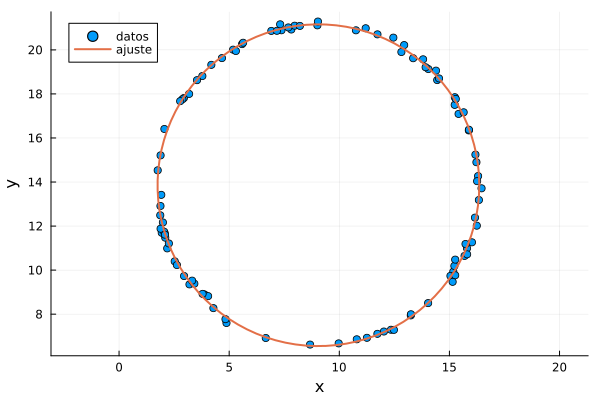

In [ ]:
ajuste_alg(datos)